In [498]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro, normaltest, skew, kurtosis, probplot
from sklearn.impute import KNNImputer

In [499]:
df = pd.read_csv("Argenprop_Enriched.tsv", sep="	")
df.head()

,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,Dormitorios,...,Hospital_cercano,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m
0,USD 2.500.000,+ $2.400.000,Jerónimo Salguero,2700.0,NaN,280 m² cubie. 3 dorm. 17 años,“TORRE BELLINI” DE REVISTA! IMPECABLE PISO MUY...,https://www.argenprop.com/departamento-en-vent...,5.0,3.0,...,R. Gutierrez,263.233350,6,741.606066,215.133556,151.484046,16,4.022667,Avenida Honduras,5
1,USD 150.000,+ $260.000,Bulnes,1600.0,NaN,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3.0,2.0,...,Dr. J. A. Fernandez,180.353080,10,493.126679,51.727490,20.279331,10,156.788297,Avenida Santa Fe,19
2,USD 330.000,+ $203.300,ARAOZ,1200.0,Piso 8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4.0,3.0,...,R. Gutierrez,188.537726,11,403.114757,429.584392,249.248104,4,96.514964,Avenida Raúl Scalabrini Ortiz,10
3,USD 270.000,+ $300.000,Honduras,3900.0,Piso 2,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4.0,2.0,...,Hospital Municipal de Oncologia M. Curie,240.873938,7,891.145341,383.017854,75.243729,7,425.495375,Avenida Coronel Niceto Vega,5
4,USD 570.000,+ $1.000.000,Castex,3300.0,NaN,140 m² cubie. 3 dorm. 40 años,PALERMO CHICO espectacular piso alto con vista...,https://www.argenprop.com/departamento-en-vent...,4.0,3.0,...,Dr. J. A. Fernandez,256.797592,4,804.138281,286.697993,217.075594,3,108.444119,Avenida Casares,7


In [500]:
df.shape

(7991, 67)

In [501]:
df.isna().sum().sort_values(ascending=False)

Toilettes                 7395
Tipo_Balcon               6946
Estado_Edificio           5366
Deptos_Por_Piso           5192
Cant_Pisos_Edificio       4859
                          ... 
Permite_Mascotas             0
Ascensor                     0
Pileta                       0
Piscina                      0
Paradas_colectivo_300m       0
Length: 67, dtype: int64

In [502]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Precio                         7991 non-null   object 
 1   Expensas                       5691 non-null   object 
 2   Calle                          7991 non-null   object 
 3   Altura                         7991 non-null   float64
 4   Piso                           4129 non-null   object 
 5   Detalles                       7885 non-null   object 
 6   Descripción                    7991 non-null   object 
 7   Link                           7991 non-null   object 
 8   Ambientes                      7750 non-null   float64
 9   Dormitorios                    6540 non-null   float64
 10  Baños                          7549 non-null   float64
 11  Toilettes                      596 non-null    float64
 12  Estado                         5295 non-null   o

# 1. Limpieza

## Conversión de tipos

In [503]:
import re

def clean_money(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    digits = re.sub(r"\D", "", text)
    return float(digits) if digits else np.nan


def clean_decimal(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    text = re.sub(r"[^0-9,\.\-]", "", text)
    if text == "":
        return np.nan

    # En las superficies del dataset la coma funciona como separador decimal.
    # El punto aparece en pocos casos como decimal con tres ceros: 149.000 -> 149.0.
    text = text.replace(",", ".")
    return pd.to_numeric(text, errors="coerce")


def clean_piso(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.upper() in ["PB", "PISO PB"]:
        return 0
    digits = re.findall(r"\d+", text)
    return float(digits[0]) if digits else np.nan

money_cols = ["Precio", "Expensas"]
surface_cols = ["Sup_Cubierta_m2", "Sup_Total_m2"]

for col in money_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_money)

for col in surface_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_decimal)

if "Piso" in df.columns:
    df["Piso"] = df["Piso"].apply(clean_piso)

numeric_cols = [
    "Precio", "Expensas", "Altura", "Piso", "Ambientes", "Dormitorios", "Baños",
    "Toilettes", "Antiguedad", "Sup_Cubierta_m2", "Sup_Total_m2", "Comuna"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df[money_cols + surface_cols + ["Piso", "Antiguedad"]].head()

,Precio,Expensas,Sup_Cubierta_m2,Sup_Total_m2,Piso,Antiguedad
0,2500000.0,2400000.0,280.0,280.0,NaN,17.0
1,150000.0,260000.0,60.0,60.0,NaN,30.0
2,330000.0,203300.0,90.0,96.0,8.0,NaN
3,270000.0,300000.0,87.0,87.0,2.0,20.0
4,570000.0,1000000.0,140.0,160.0,NaN,40.0


In [504]:
# Valores imposibles o claramente inconsistentes
if "Antiguedad" in df.columns:
    df.loc[df["Antiguedad"] < 0, "Antiguedad"] = np.nan

for col in ["Precio", "Expensas", "Sup_Cubierta_m2", "Sup_Total_m2"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

mask_sup = df["Sup_Cubierta_m2"] > df["Sup_Total_m2"]
df.loc[mask_sup, "Sup_Cubierta_m2"] = df.loc[mask_sup, "Sup_Total_m2"]

print("Filas con Sup_Cubierta_m2 > Sup_Total_m2:", (df["Sup_Cubierta_m2"] > df["Sup_Total_m2"]).sum())
df[["Precio", "Expensas", "Antiguedad", "Sup_Cubierta_m2", "Sup_Total_m2"]].describe()

Filas con Sup_Cubierta_m2 > Sup_Total_m2: 0


,Precio,Expensas,Antiguedad,Sup_Cubierta_m2,Sup_Total_m2
count,7.935000e+03,5.691000e+03,5339.000000,7398.000000,7641.000000
mean,1.849257e+05,2.405112e+05,40.242367,66.734679,74.457514
std,2.297892e+05,4.694114e+05,43.536521,46.838578,54.158090
min,1.000000e+04,1.040000e+03,0.000000,1.000000,1.000000
25%,8.500000e+04,1.100000e+05,20.000000,39.000000,42.000000
50%,1.280000e+05,1.675000e+05,42.000000,54.000000,60.000000
75%,1.990000e+05,2.700000e+05,50.000000,77.575000,86.000000
max,5.500000e+06,3.019095e+07,2001.000000,665.000000,770.000000


In [505]:
variable = "Sup_Cubierta_m2"
caracteres_unicos = sorted(set("".join(df[variable].dropna().astype(str))))
caracteres_unicos

['.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

## Normalidad y QQ-plots

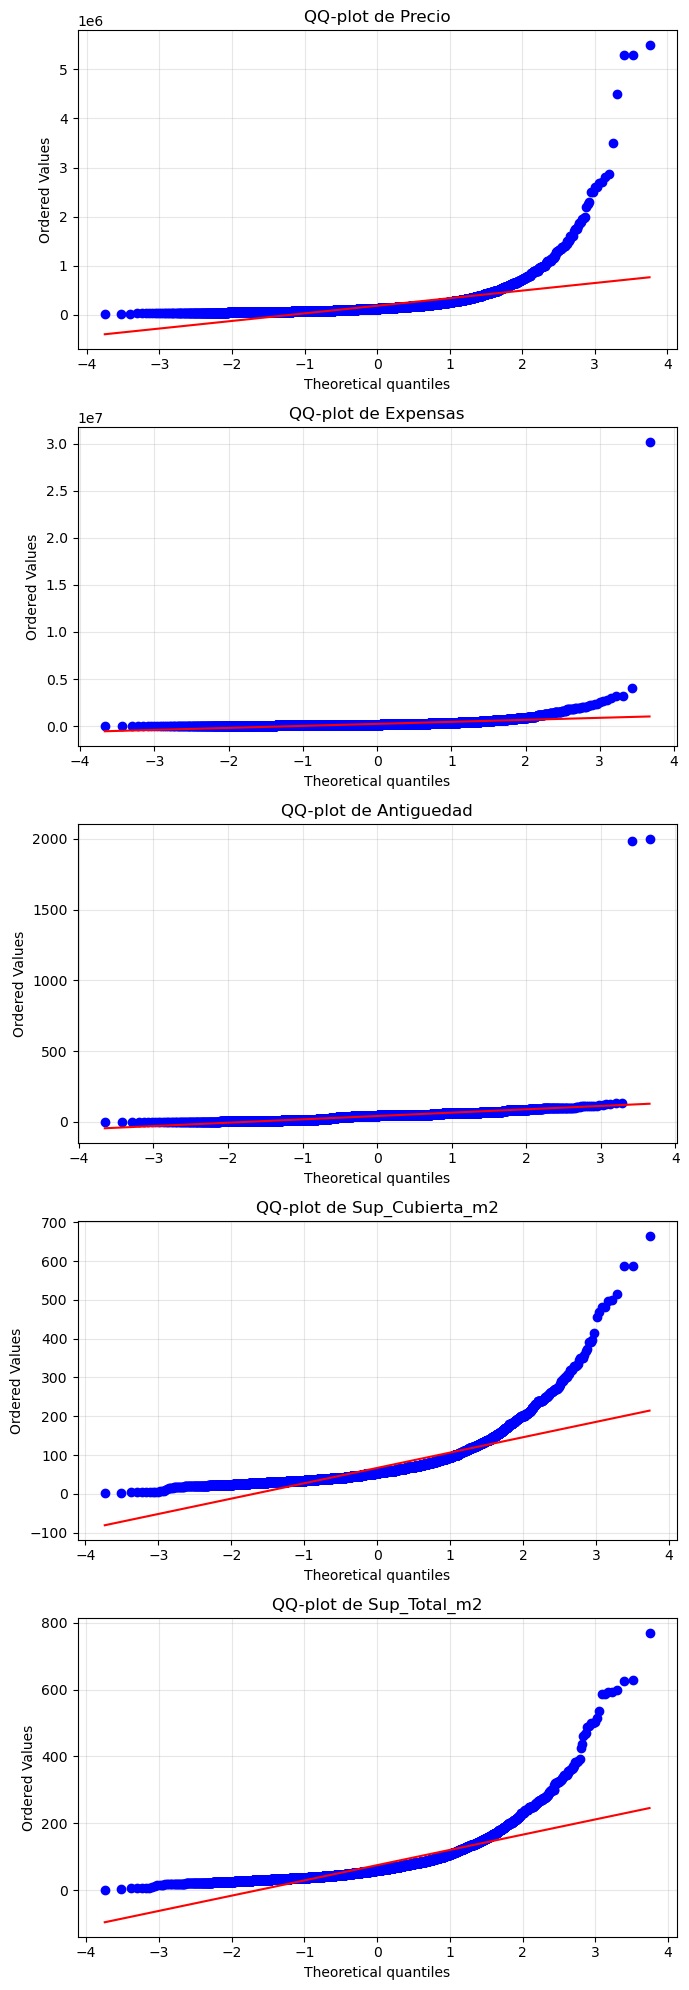

,variable,n,shapiro_stat,shapiro_p_value,dagostino_stat,dagostino_p_value,skewness,kurtosis,normal_shapiro_5pct,normal_dagostino_5pct
0,Precio,7935,0.433830,7.362863e-83,11737.432570,0.0,8.884744,141.459543,False,False
1,Expensas,5691,0.199296,1.162541e-90,17519.054679,0.0,46.353525,2913.252700,False,False
2,Antiguedad,5339,0.287771,5.509816e-88,14596.827157,0.0,33.816112,1514.070922,False,False
3,Sup_Cubierta_m2,7398,0.703500,2.944442e-69,5564.572759,0.0,3.389394,20.172216,False,False
4,Sup_Total_m2,7641,0.719766,3.947034e-68,5807.764647,0.0,3.433578,20.584688,False,False


In [506]:
variables = [
    "Precio",
    "Expensas",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]
variables = [v for v in variables if v in df.columns]

resultados_normalidad = []

fig, axes = plt.subplots(
    nrows=len(variables),
    ncols=1,
    figsize=(7, 4 * len(variables))
)

if len(variables) == 1:
    axes = [axes]

for ax, var in zip(axes, variables):
    x = pd.to_numeric(df[var], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) >= 3:
        x_shapiro = x.sample(5000, random_state=42) if len(x) > 5000 else x
        shapiro_stat, shapiro_p = shapiro(x_shapiro)
        dagostino_stat, dagostino_p = normaltest(x) if len(x) >= 8 else (np.nan, np.nan)

        resultados_normalidad.append({
            "variable": var,
            "n": len(x),
            "shapiro_stat": shapiro_stat,
            "shapiro_p_value": shapiro_p,
            "dagostino_stat": dagostino_stat,
            "dagostino_p_value": dagostino_p,
            "skewness": skew(x),
            "kurtosis": kurtosis(x)
        })

        probplot(x, dist="norm", plot=ax)
        ax.set_title(f"QQ-plot de {var}")
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f"{var}: datos insuficientes")
        ax.axis("off")

plt.tight_layout()
plt.show()

resultados_normalidad = pd.DataFrame(resultados_normalidad)

if not resultados_normalidad.empty:
    resultados_normalidad["normal_shapiro_5pct"] = resultados_normalidad["shapiro_p_value"] > 0.05
    resultados_normalidad["normal_dagostino_5pct"] = resultados_normalidad["dagostino_p_value"] > 0.05

resultados_normalidad

## Transformación logarítmica y outliers

In [507]:
vars_transformar = [
    "Precio",
    "Expensas",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]
vars_transformar = [v for v in vars_transformar if v in df.columns]

for var in vars_transformar:
    df[var] = pd.to_numeric(df[var], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df.loc[df[var] < 0, var] = np.nan
    df[f"log_{var}"] = np.log1p(df[var])
    media = df[f"log_{var}"].mean(skipna=True)
    desvio = df[f"log_{var}"].std(skipna=True)
    df[f"z_log_{var}"] = (df[f"log_{var}"] - media) / desvio if desvio and not np.isnan(desvio) else np.nan

cols_check = []
for var in vars_transformar:
    cols_check.extend([var, f"log_{var}", f"z_log_{var}"])

df[cols_check].head()

,Precio,log_Precio,z_log_Precio,Expensas,log_Expensas,z_log_Expensas,Antiguedad,log_Antiguedad,z_log_Antiguedad,Sup_Cubierta_m2,log_Sup_Cubierta_m2,z_log_Sup_Cubierta_m2,Sup_Total_m2,log_Sup_Total_m2,z_log_Sup_Total_m2
0,2500000.0,14.731802,4.285001,2400000.0,14.690980,3.171403,17.0,2.890372,-0.675143,280.0,5.638355,2.989742,280.0,5.638355,2.711534
1,150000.0,11.918397,0.117400,260000.0,12.468441,0.518287,30.0,3.433987,-0.031980,60.0,4.110874,0.096580,60.0,4.110874,-0.083558
2,330000.0,12.706851,1.285366,203300.0,12.222443,0.224632,NaN,NaN,NaN,90.0,4.510860,0.854182,96.0,4.574711,0.765204
3,270000.0,12.506181,0.988106,300000.0,12.611541,0.689111,20.0,3.044522,-0.492764,87.0,4.477337,0.790688,87.0,4.477337,0.587022
4,570000.0,13.253393,2.094980,1000000.0,13.815512,2.126328,40.0,3.713572,0.298802,140.0,4.948760,1.683598,160.0,5.081404,1.692387


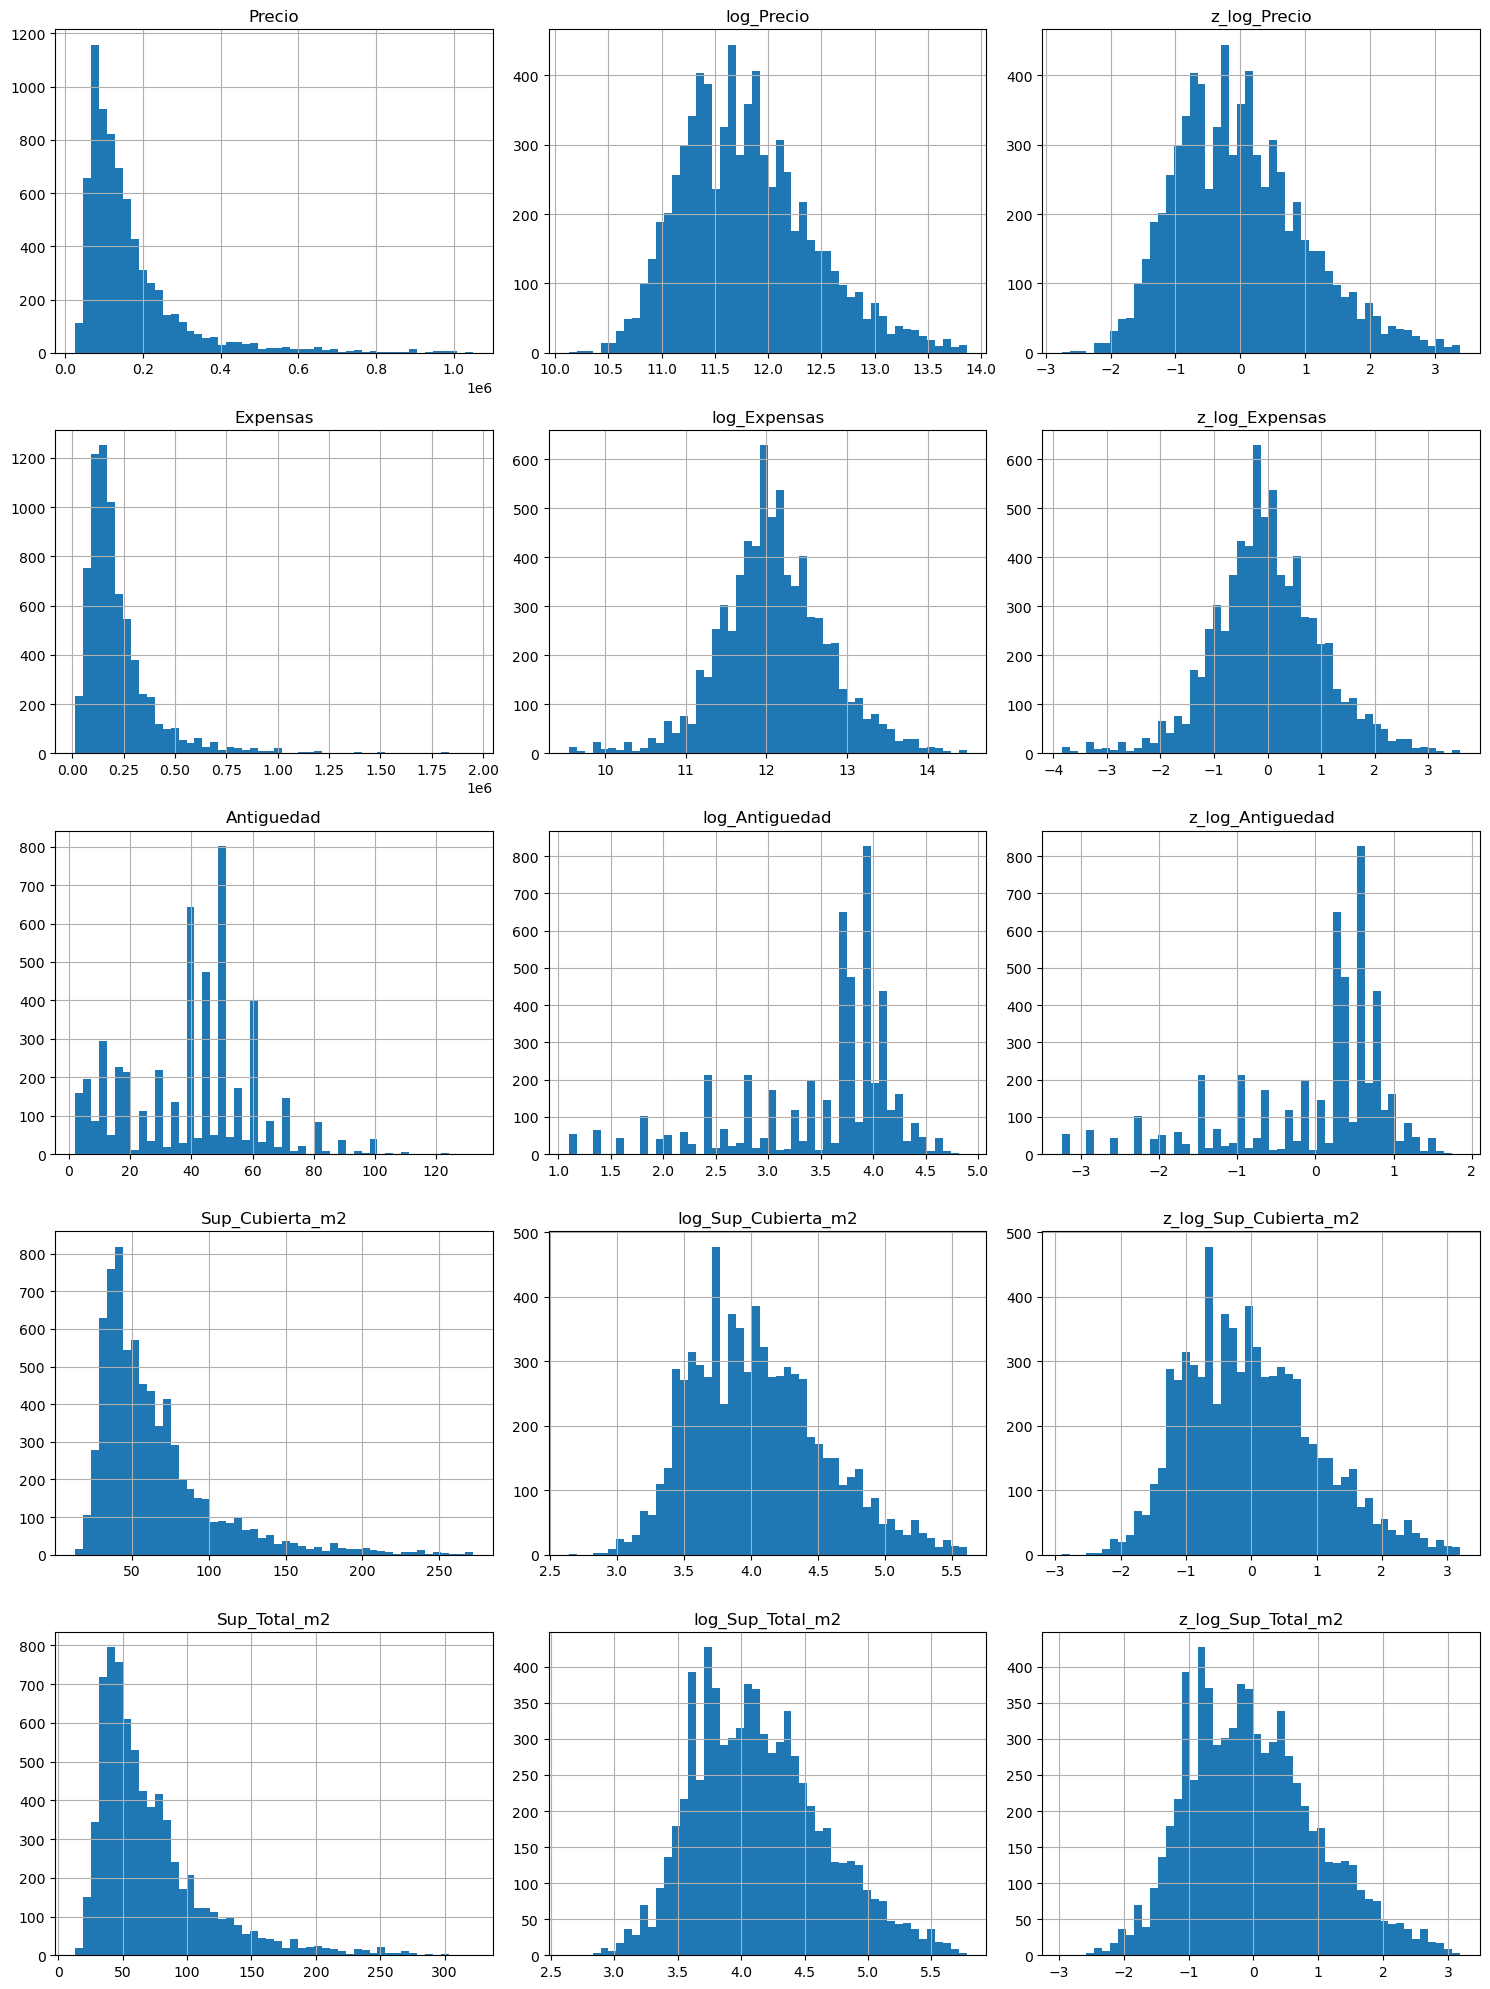

In [518]:
variables = [
    "Precio",
    "Expensas",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]

variables = [v for v in variables if v in df.columns]

fig, axes = plt.subplots(
    nrows=len(variables),
    ncols=3,
    figsize=(15, 4 * len(variables))
)

if len(variables) == 1:
    axes = np.array([axes])

for i, var in enumerate(variables):
    df[var] = pd.to_numeric(df[var], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df.loc[df[var] < 0, var] = np.nan

    df[f"log_{var}"] = np.log1p(df[var])

    media = df[f"log_{var}"].mean(skipna=True)
    desvio = df[f"log_{var}"].std(skipna=True)

    df[f"z_log_{var}"] = (
        (df[f"log_{var}"] - media) / desvio
        if desvio and not np.isnan(desvio)
        else np.nan
    )

    df[var].hist(ax=axes[i, 0], bins=50)
    axes[i, 0].set_title(var)

    df[f"log_{var}"].hist(ax=axes[i, 1], bins=50)
    axes[i, 1].set_title(f"log_{var}")

    df[f"z_log_{var}"].hist(ax=axes[i, 2], bins=50)
    axes[i, 2].set_title(f"z_log_{var}")

plt.tight_layout()
plt.show()


In [509]:
outlier_tables = {}

for var in vars_transformar:
    z_col = f"z_log_{var}"
    outliers = df[df[z_col].abs() > 3].copy()
    outlier_tables[var] = outliers[[var, f"log_{var}", z_col]].sort_values(z_col, ascending=False)
    print(f"{var}: {len(outliers)} outliers")

outlier_tables["Precio"].head(20)

Precio: 77 outliers
Expensas: 90 outliers
Antiguedad: 95 outliers
Sup_Cubierta_m2: 59 outliers
Sup_Total_m2: 53 outliers


,Precio,log_Precio,z_log_Precio
6600,5500000.0,15.520259,5.452971
7821,5300000.0,15.483218,5.398101
4840,5300000.0,15.483218,5.398101
4899,4500000.0,15.319588,5.155711
4836,3500000.0,15.068274,4.783429
7379,2870844.0,14.870117,4.489892
4848,2800000.0,14.845130,4.452879
7366,2700000.0,14.808763,4.399006
5489,2690000.0,14.805052,4.393509
4462,2600000.0,14.771022,4.343100


In [510]:
vars_z = [f"z_log_{var}" for var in vars_transformar if f"z_log_{var}" in df.columns]
mask_outliers = (df[vars_z].abs() > 3).any(axis=1)

print("Filas antes:", df.shape[0])
print("Outliers a eliminar:", mask_outliers.sum())

df = df.loc[~mask_outliers].copy()

print("Filas despu?s:", df.shape[0])

Filas antes: 7991
Outliers a eliminar: 293
Filas despu?s: 7698


## Imputación y tratamiento de NAs

In [511]:
df.isna().sum().sort_values(ascending=False)

Toilettes              7131
Tipo_Balcon            6690
Estado_Edificio        5157
Deptos_Por_Piso        5031
Cant_Pisos_Edificio    4714
                       ... 
Seguridad_24hs            0
Vigilancia                0
Latitud                   0
Longitud                  0
Ascensor                  0
Length: 77, dtype: int64

In [512]:
df = df.drop(
    columns=[
        "Precio_Ficha", "Expensas_Ficha", "Procesada", "Toilettes", "Tipo_Balcon",
        "Estado_Edificio", "Deptos_Por_Piso", "Cant_Pisos_Edificio"
    ],
    errors="ignore"
)

df = df.dropna(subset=[c for c in ["Comuna", "Barrio", "Baños"] if c in df.columns]).copy()

df.isna().sum().sort_values(ascending=False)

Piso                3628
Tipo_Unidad         2725
Estado              2370
z_log_Antiguedad    2298
log_Antiguedad      2298
                    ... 
Seguridad_24hs         0
Vigilancia             0
Latitud                0
Longitud               0
Parrilla               0
Length: 69, dtype: int64

In [513]:
df_imputed = df.copy()

knn_cols = [
    "Precio", "Expensas", "Sup_Cubierta_m2", "Sup_Total_m2", "Ambientes",
    "Dormitorios"]
knn_cols = [c for c in knn_cols if c in df_imputed.columns]

for col in knn_cols:
    df_imputed[col] = pd.to_numeric(df_imputed[col], errors="coerce")

df_imputed[knn_cols] = df_imputed[knn_cols].replace([np.inf, -np.inf], np.nan)

imputer = KNNImputer(n_neighbors=5, weights="distance", keep_empty_features=True)
imputed_array = imputer.fit_transform(df_imputed[knn_cols])

df_imputed[knn_cols] = pd.DataFrame(
    imputed_array,
    columns=knn_cols,
    index=df_imputed.index
)

# Fallback con mediana para garantizar que no queden NAs en las variables num?ricas imputadas.
df_imputed[knn_cols] = df_imputed[knn_cols].fillna(df_imputed[knn_cols].median(numeric_only=True))

# Variables discretas que conviene dejar como enteros despu?s del KNN.
# Baños no se imputa: las filas sin Baños se dropean antes del KNN.
for col in ["Ambientes", "Dormitorios", "Piso", "Antiguedad", "Comuna"]:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].round().astype("Int64")

mask_sup = df_imputed["Sup_Cubierta_m2"] > df_imputed["Sup_Total_m2"]
df_imputed.loc[mask_sup, "Sup_Cubierta_m2"] = df_imputed.loc[mask_sup, "Sup_Total_m2"]

print("NAs despu?s de imputar variables num?ricas:")
print(df_imputed[knn_cols].isna().sum().sort_values(ascending=False).head(20))
print("Filas con Sup_Cubierta_m2 > Sup_Total_m2:", (df_imputed["Sup_Cubierta_m2"] > df_imputed["Sup_Total_m2"]).sum())

NAs despu?s de imputar variables num?ricas:
Precio             0
Expensas           0
Sup_Cubierta_m2    0
Sup_Total_m2       0
Ambientes          0
Dormitorios        0
dtype: int64
Filas con Sup_Cubierta_m2 > Sup_Total_m2: 0


In [519]:
df_imputed["Piso"] = df_imputed["Piso"].astype(str)
df_imputed["Piso"].replace("<NA>","No disponible")

1       No disponible
2                   8
3                   2
4       No disponible
5                   5
            ...      
7986                7
7987    No disponible
7988    No disponible
7989                1
7990    No disponible
Name: Piso, Length: 7250, dtype: object

In [520]:
fill_values = {
    "Detalles": "No tiene detalles",
    "Estado": "No disponible",
    "Tipo_Unidad": "No disponible",
    "Disposicion": "No disponible",
    "Descripción": "No disponible",
}

for col, value in fill_values.items():
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].fillna(value)

# Si quedaron columnas log/z_log con NAs, no las usamos como variables finales.
df_imputed = df_imputed.drop(
    columns=[c for c in df_imputed.columns if c.startswith("log_") or c.startswith("z_log_")],
    errors="ignore"
)

df_imputed.isna().sum().sort_values(ascending=False)

Antiguedad                       2298
Precio                              0
Comuna                              0
Pileta                              0
Piscina                             0
Parrilla                            0
SUM                                 0
Gimnasio                            0
Sauna                               0
Laundry                             0
Seguridad_24hs                      0
Vigilancia                          0
Latitud                             0
Longitud                            0
Barrio                              0
Dist_Subte_m                        0
Permite_Mascotas                    0
Subte_cercano                       0
Linea_subte                         0
Dist_Hospital_m                     0
Hospital_cercano                    0
Dist_Colegio_m                      0
Colegios_500m                       0
Dist_Comisaria_m                    0
Dist_Gimnasio_m                     0
Dist_Supermercado_m                 0
Supermercado

In [516]:
df = df_imputed.copy()
print("Shape final:", df.shape)
df.head()

Shape final: (7250, 59)


,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,Dormitorios,...,Hospital_cercano,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m
1,150000.0,260000.0,Bulnes,1600.0,<NA>,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3,2,...,Dr. J. A. Fernandez,180.353080,10,493.126679,51.727490,20.279331,10,156.788297,Avenida Santa Fe,19
2,330000.0,203300.0,ARAOZ,1200.0,8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4,3,...,R. Gutierrez,188.537726,11,403.114757,429.584392,249.248104,4,96.514964,Avenida Raúl Scalabrini Ortiz,10
3,270000.0,300000.0,Honduras,3900.0,2,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4,2,...,Hospital Municipal de Oncologia M. Curie,240.873938,7,891.145341,383.017854,75.243729,7,425.495375,Avenida Coronel Niceto Vega,5
4,570000.0,1000000.0,Castex,3300.0,<NA>,140 m² cubie. 3 dorm. 40 años,PALERMO CHICO espectacular piso alto con vista...,https://www.argenprop.com/departamento-en-vent...,4,3,...,Dr. J. A. Fernandez,256.797592,4,804.138281,286.697993,217.075594,3,108.444119,Avenida Casares,7
5,98000.0,150000.0,GURRUCHAGA,2100.0,5,31 m² cubie. 15 años 1 baño,VENTA - DEPARTAMENTO 1 AMBIENTE AL FRENTE EN P...,https://www.argenprop.com/departamento-en-vent...,1,1,...,R. Gutierrez,153.610169,5,461.483469,393.568008,85.286744,6,378.802881,Avenida Raúl Scalabrini Ortiz,7
